In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer



import nltk
from nltk.corpus import stopwords

In [3]:
!pip install wordcloud

In [4]:
from wordcloud import WordCloud

In [126]:
df = pd.read_csv("./data/raw/raw_analyst_ratings.csv")

In [127]:
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [128]:
df.shape

(1407328, 6)

In [129]:
df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')

In [130]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


In [132]:
df["headline_length"] = df["headline"].apply(len)

In [133]:
df.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87


In [134]:
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [135]:
print(df[df["headline_length"] <= 3]["headline"].unique())


['SPY' 'SRS' 'J.P' 'AMJ' 'PCP' 'QID' 'SUN' 'TJX' 'WNR']


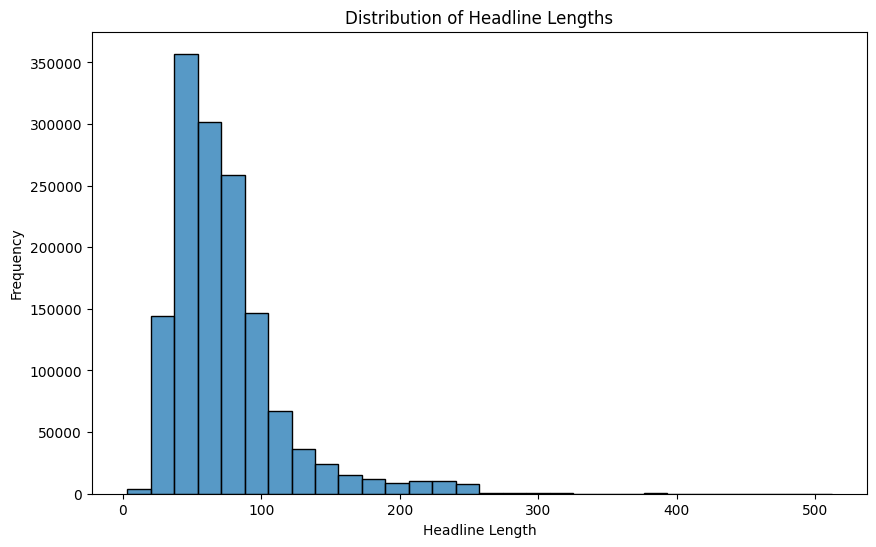

In [136]:
plt.figure(figsize=(10,6))
sns.histplot(df["headline_length"], bins=30)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

In [137]:
publisher_counts = df["publisher"].value_counts().head(10)
publisher_counts

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

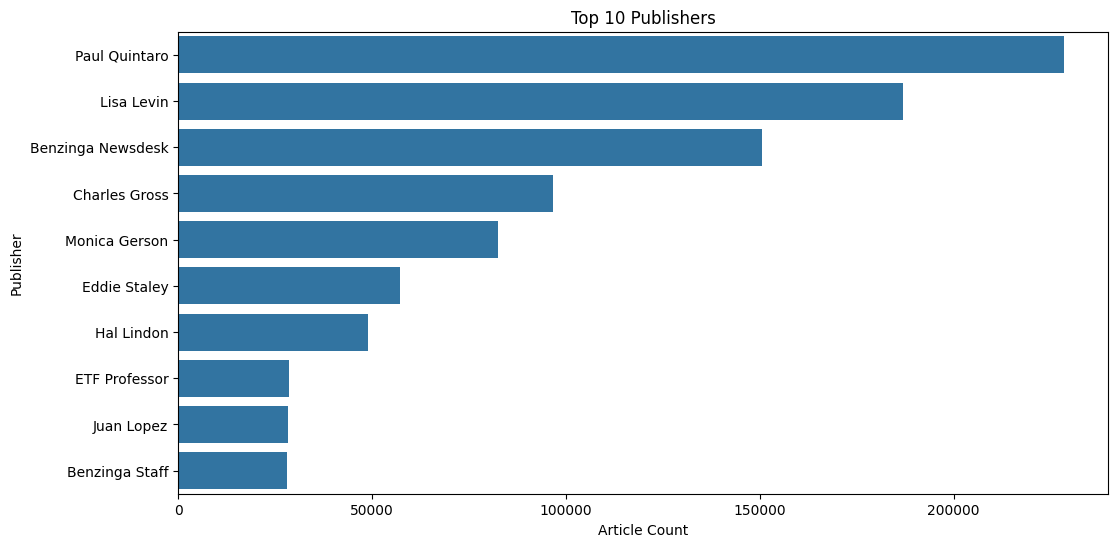

In [138]:
plt.figure(figsize=(12,6))
sns.barplot(x=publisher_counts.values, y=publisher_counts.index)

plt.title("Top 10 Publishers")
plt.xlabel("Article Count")
plt.ylabel("Publisher")

plt.show()

In [139]:
df.head ()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87


In [140]:
df.tail ()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX,38
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX,52
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX,56
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX,54
1407327,1413848,China Zenix Auto International Opens For Tradi...,https://www.benzinga.com/news/ipos/11/05/10789...,Allie Wickman,2011-05-12 00:00:00,ZX,81


In [143]:
df["date"] = pd.to_datetime(df["date"], format='mixed', utc=True)

In [144]:
df["date"].head()

0   2020-06-05 14:30:54+00:00
1   2020-06-03 14:45:20+00:00
2   2020-05-26 08:30:07+00:00
3   2020-05-22 16:45:06+00:00
4   2020-05-22 15:38:59+00:00
Name: date, dtype: datetime64[ns, UTC]

In [145]:
df["date"].tail()

1407323   2011-08-29 00:00:00+00:00
1407324   2011-06-22 00:00:00+00:00
1407325   2011-06-21 00:00:00+00:00
1407326   2011-06-21 00:00:00+00:00
1407327   2011-05-12 00:00:00+00:00
Name: date, dtype: datetime64[ns, UTC]

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 7 columns):
 #   Column           Non-Null Count    Dtype              
---  ------           --------------    -----              
 0   Unnamed: 0       1407328 non-null  int64              
 1   headline         1407328 non-null  object             
 2   url              1407328 non-null  object             
 3   publisher        1407328 non-null  object             
 4   date             1407328 non-null  datetime64[ns, UTC]
 5   stock            1407328 non-null  object             
 6   headline_length  1407328 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(2), object(4)
memory usage: 75.2+ MB


In [147]:
df["date"] = pd.to_datetime(df["date"])

In [148]:
df["day"] = df["date"].dt.date

In [149]:
daily_counts = df.groupby("day").size()

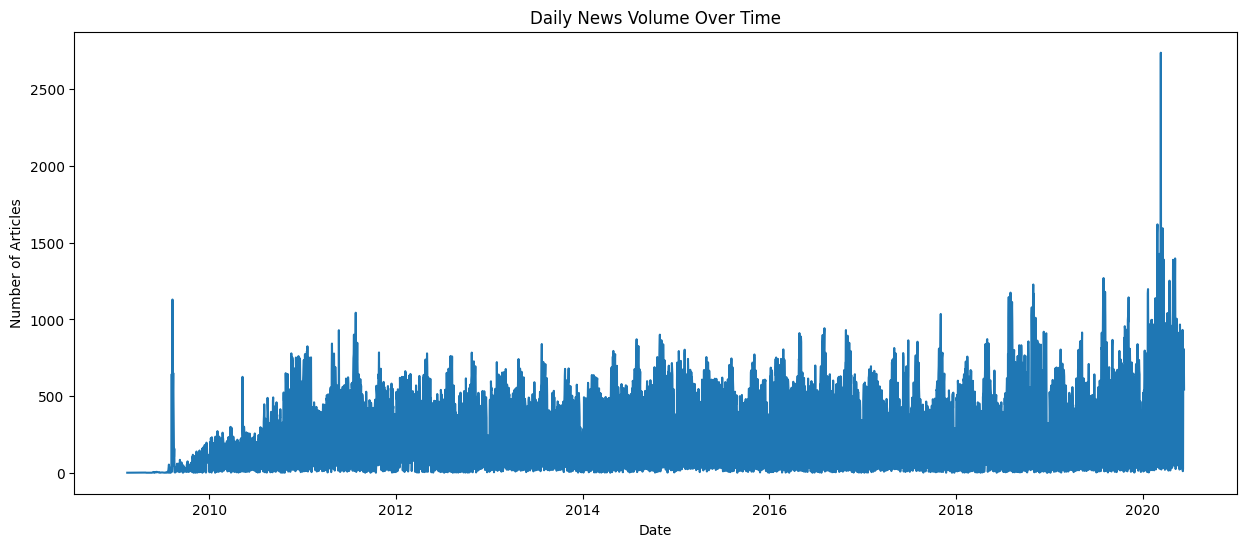

In [150]:
plt.figure(figsize=(15,6))

daily_counts.plot()

plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [151]:
df["hour"] = df["date"].dt.hour

In [152]:
hour_counts = df["hour"].value_counts().sort_index()

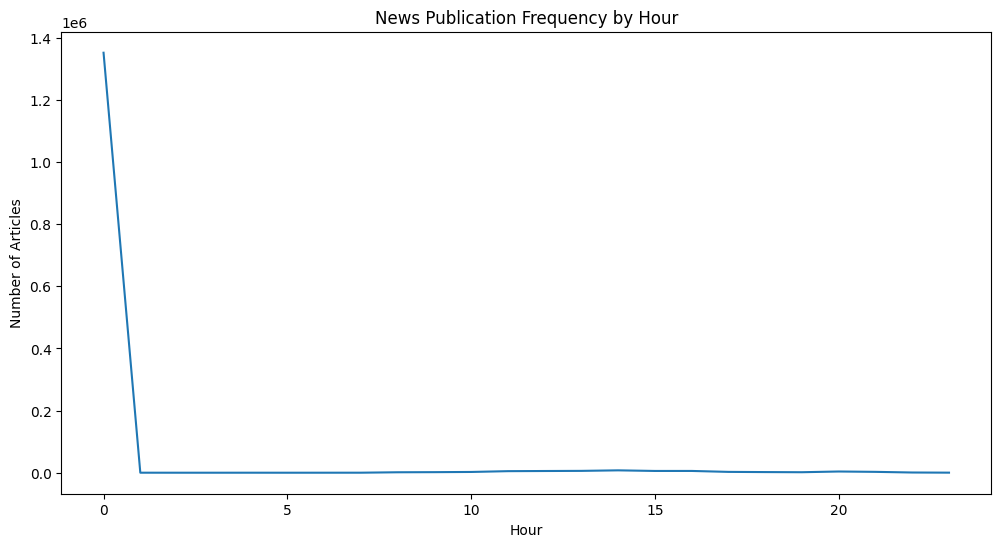

In [153]:
plt.figure(figsize=(12,6))

sns.lineplot(x=hour_counts.index, y=hour_counts.values)

plt.title("News Publication Frequency by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")

plt.show()

In [154]:
vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df["headline"])

word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values(by="count", ascending=False)

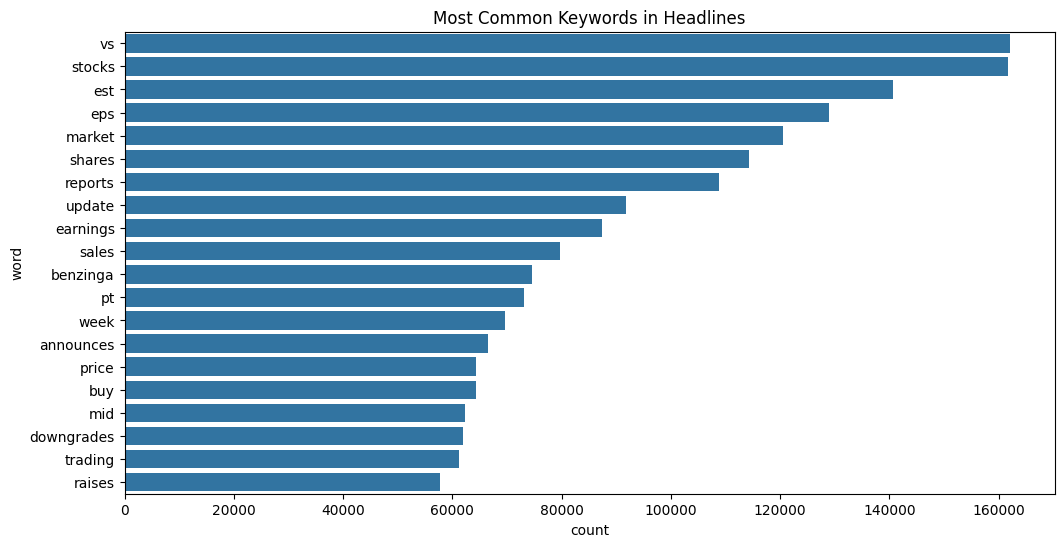

In [155]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="count",
    y="word",
    data=word_counts
)

plt.title("Most Common Keywords in Headlines")

plt.show()

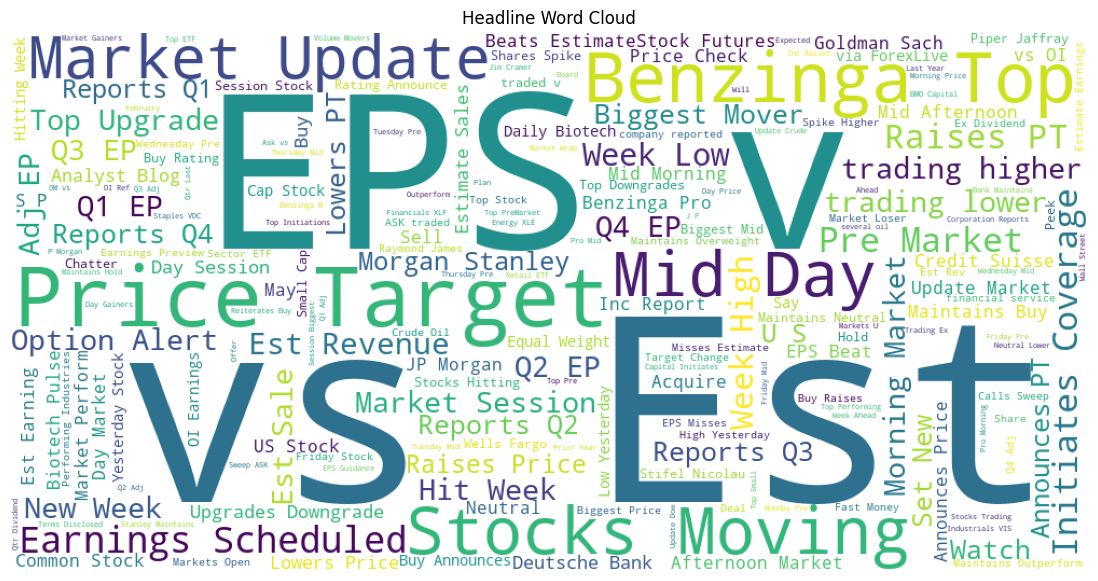

In [156]:
text = " ".join(df["headline"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Headline Word Cloud")
plt.show()

In [158]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X_tfidf = tfidf.fit_transform(df["headline"])

scores = pd.DataFrame({
    "term": tfidf.get_feature_names_out(),
    "score": X_tfidf.sum(axis=0).A1
})

scores = scores.sort_values(by="score", ascending=False)
scores

,term,score
15,stocks,120048.420657
7,market,83037.704493
14,shares,77559.971297
4,earnings,75181.331827
18,vs,65464.128259
12,reports,64127.172118
17,update,63627.866238
1,benzinga,62142.509181
5,eps,61187.454960
0,announces,55964.729030


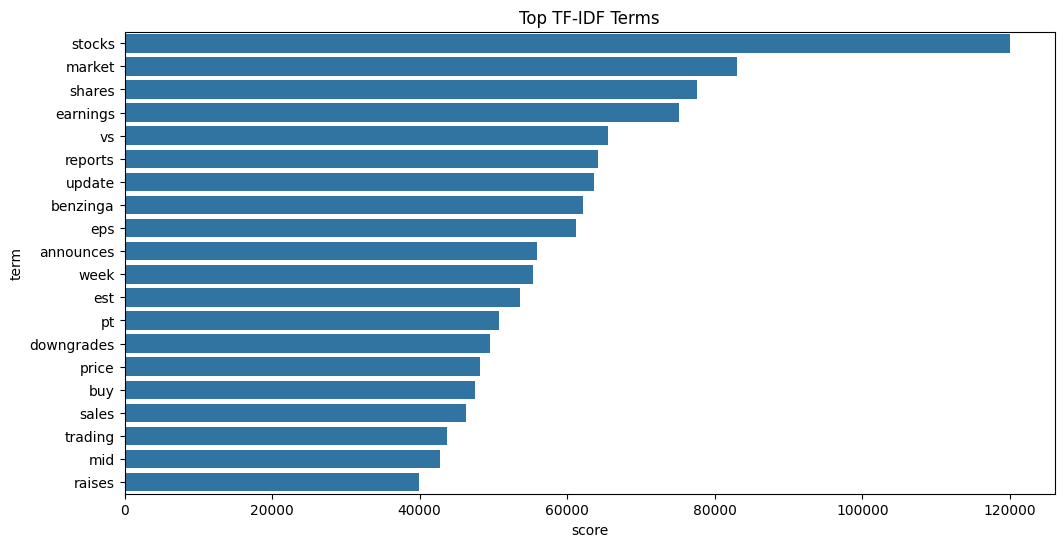

In [159]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="score",
    y="term",
    data=scores
)

plt.title("Top TF-IDF Terms")

plt.show()

In [160]:
top_stocks = df["stock"].value_counts().head(10)

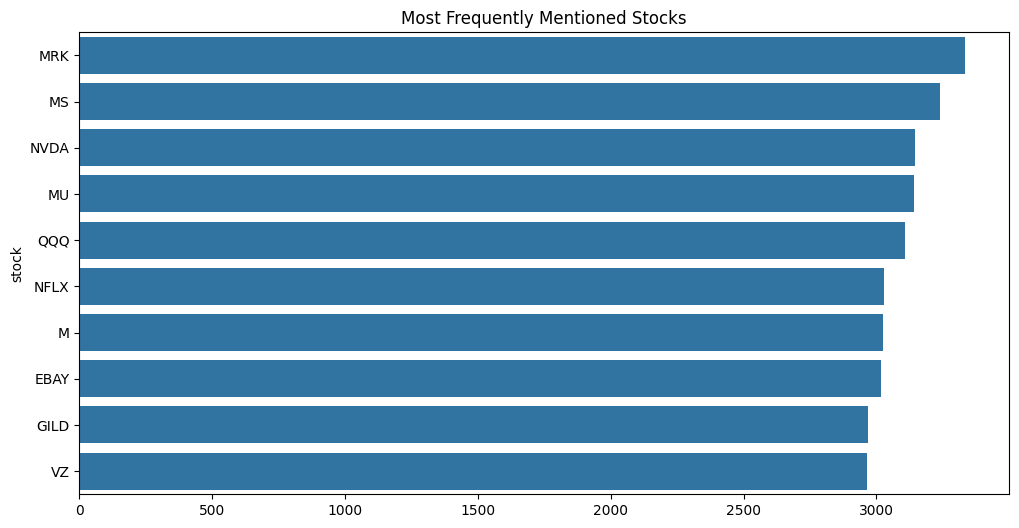

In [161]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_stocks.values,
    y=top_stocks.index
)

plt.title("Most Frequently Mentioned Stocks")

plt.show()

In [162]:
df["domain"] = df["publisher"].str.extract(r'@(.+)')

In [163]:
df["domain"].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64